In [15]:
import os
import glob
import random
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.manifold import TSNE
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# 固定随机种子
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

# 路径定义
BASE_DIR = r"D:\Project_Github\Indo-Pacific-humpback-dolphin"
DATA_DIR = os.path.join(BASE_DIR)

# 正样本 (Weak Reverberation)
POS_DIR = os.path.join(DATA_DIR, "05_DistinguishbyEnergy", "Weak_Reverberation")
# 负样本：从之前聚类或筛选后的 CSV 中读取路径
NEG_CSV_PATH = os.path.join(BASE_DIR, "04_Classification", "filtered_underwater_negatives.csv")
# 难度测试集正样本 (Strong_Reverberation)
HARD_POS_DIR = os.path.join(DATA_DIR, "05_DistinguishbyEnergy", "Strong_Reverberation")

print("Paths initialized.")

Paths initialized.


In [16]:
def get_all_wavs(directory):
    return glob.glob(os.path.join(directory, "**", "*.wav"), recursive=True)

# 1. 获取正样本文件路径列表
all_pos_files = get_all_wavs(POS_DIR)
print(f"Total positive files found in disk: {len(all_pos_files)}")
selected_pos_paths = all_pos_files[:884] 

# 2. 获取负样本文件路径列表 (从 CSV 读取)
if not os.path.exists(NEG_CSV_PATH):
    raise FileNotFoundError(f"错误：找不到负样本CSV文件 {NEG_CSV_PATH}，请确保已生成该文件。")

df_neg = pd.read_csv(NEG_CSV_PATH)
all_neg_paths_from_csv = df_neg['path'].tolist() # 提取路径列
print(f"Total negative paths loaded from CSV: {len(all_neg_paths_from_csv)}")

random.shuffle(all_neg_paths_from_csv)

# 采样 884 个做训练/常规测试，100 个做难度测试
selected_neg_main_paths = all_neg_paths_from_csv[:884]
selected_neg_hard_paths = all_neg_paths_from_csv[884:984] if len(all_neg_paths_from_csv) >= 984 else all_neg_paths_from_csv[-100:]

# 3. 获取难度正样本文件路径列表
all_hard_pos_files = get_all_wavs(HARD_POS_DIR)
selected_hard_pos_paths = all_hard_pos_files[:100]

print(f"Paths Selection Done.")

Total positive files found in disk: 15834
Total negative paths loaded from CSV: 9069
Paths Selection Done.


In [17]:
def load_waveforms_from_paths(path_list, target_length=512, augment=True):
    """根据路径列表加载音频并转为波形数组"""
    data = []
    for f in path_list:
        try:
            if not os.path.exists(f):
                continue
            # 实际加载音频文件
            y, sr = librosa.load(f, sr=None) 
            
            # 填充或截断到固定长度
            if len(y) > target_length:
                y = y[:target_length]
            else:
                y = np.pad(y, (0, max(0, target_length - len(y))), 'constant')
            
            # 平移增强 (仅对训练/基础测试数据)
            if augment:
                shift = np.random.randint(-50, 50) 
                y = np.roll(y, shift)
            data.append(y)
        except Exception as e:
            pass
    return np.array(data)

WAVE_LEN = 116

print("Loading actual waveforms from disk... (This may take a while)")
X_pos = load_waveforms_from_paths(selected_pos_paths, target_length=WAVE_LEN)
X_neg = load_waveforms_from_paths(selected_neg_main_paths, target_length=WAVE_LEN)

X_hard_pos = load_waveforms_from_paths(selected_hard_pos_paths, target_length=WAVE_LEN, augment=False)
X_hard_neg = load_waveforms_from_paths(selected_neg_hard_paths, target_length=WAVE_LEN, augment=False)

# 构建数据集
X = np.vstack([X_pos, X_neg])
y = np.array([1]*len(X_pos) + [0]*len(X_neg))

X_hard = np.vstack([X_hard_pos, X_hard_neg])
y_hard = np.array([1]*len(X_hard_pos) + [0]*len(X_hard_neg))

print(f"Final Dataset Shape: {X.shape}, Hard Test Shape: {X_hard.shape}")

Loading actual waveforms from disk... (This may take a while)
Final Dataset Shape: (1768, 116), Hard Test Shape: (200, 116)


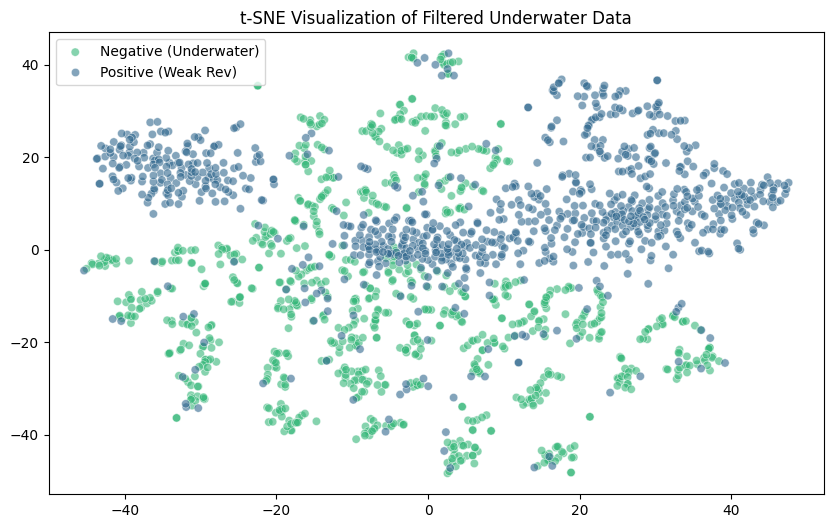

In [18]:
tsne = TSNE(n_components=2, random_state=SEED, init='pca', learning_rate='auto')
X_embedded = tsne.fit_transform(X)

plt.figure(figsize=(10, 6))
sns.scatterplot(x=X_embedded[:,0], y=X_embedded[:,1], hue=y, palette='viridis', alpha=0.6)
plt.title("t-SNE Visualization of Filtered Underwater Data")
plt.legend(["Negative (Underwater)", "Positive (Weak Rev)"])
plt.show()

In [19]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED, stratify=y)

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', C=1.0, gamma='scale', random_state=SEED))
])

cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(svm_pipeline, X_train, y_train, cv=cv, scoring='accuracy')

print(f"SVM 5-Fold CV Accuracy (on Filtered Data): {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")

SVM 5-Fold CV Accuracy (on Filtered Data): 0.7108 (+/- 0.0246)


In [20]:
svm_pipeline.fit(X_train, y_train)
y_pred = svm_pipeline.predict(X_test)

print("Classification Report on Test Set (Balanced Filtered Noise):")
print(classification_report(y_test, y_pred, target_names=['FalseClick', 'PositiveClick']))

Classification Report on Test Set (Balanced Filtered Noise):
               precision    recall  f1-score   support

   FalseClick       1.00      0.46      0.63       177
PositiveClick       0.65      1.00      0.79       177

     accuracy                           0.73       354
    macro avg       0.82      0.73      0.71       354
 weighted avg       0.82      0.73      0.71       354



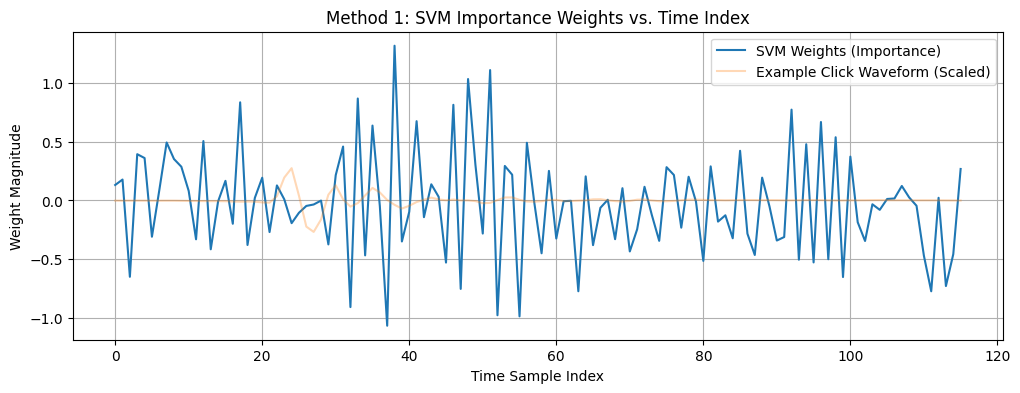

分析结论：如果权重只在某个窄脉冲处剧烈波动，说明模型是'峰值检测器'；如果权重平铺在较长区域，说明模型在关注信号的持续性。


In [25]:
# --- 方法一：训练线性 SVM 以分析权重分布 ---
from sklearn.svm import SVC

# 为了分析特征重要性，我们专门训练一个线性核模型
lin_svm_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='linear', random_state=SEED))
])
lin_svm_pipe.fit(X_train, y_train)

# 获取权重 (Linear SVM 的 coef_ 代表了每个采样点的重要性)
weights = lin_svm_pipe.named_steps['svm'].coef_[0]

plt.figure(figsize=(12, 4))
plt.plot(weights, label='SVM Weights (Importance)')
# 为了对比，画一个典型的正样本波形
plt.plot(X_pos[50] * np.max(np.abs(weights)), alpha=0.3, label='Example Click Waveform (Scaled)')
plt.title("Method 1: SVM Importance Weights vs. Time Index")
plt.xlabel("Time Sample Index")
plt.ylabel("Weight Magnitude")
plt.legend()
plt.grid(True)
plt.show()

print("分析结论：如果权重只在某个窄脉冲处剧烈波动，说明模型是'峰值检测器'；"
      "如果权重平铺在较长区域，说明模型在关注信号的持续性。")

Classification Report on Hard Test Set (Strong Reverberation + Filtered Noise):
               precision    recall  f1-score   support

   FalseClick       1.00      0.44      0.61       100
PositiveClick       0.64      1.00      0.78       100

     accuracy                           0.72       200
    macro avg       0.82      0.72      0.70       200
 weighted avg       0.82      0.72      0.70       200



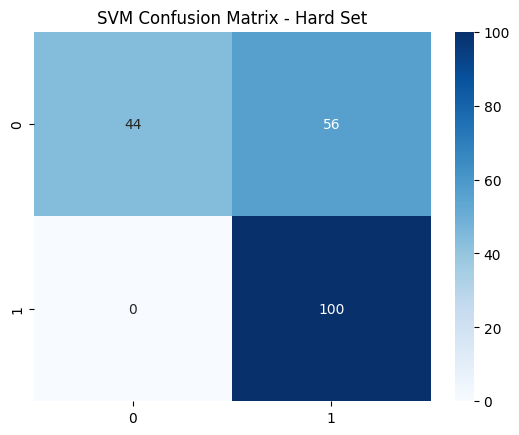

In [22]:
y_hard_pred = svm_pipeline.predict(X_hard)

print("Classification Report on Hard Test Set (Strong Reverberation + Filtered Noise):")
print(classification_report(y_hard, y_hard_pred, target_names=['FalseClick', 'PositiveClick']))

cm = confusion_matrix(y_hard, y_hard_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('SVM Confusion Matrix - Hard Set')
plt.show()

正在测试模型对不同波形特征的依赖度...

--- Original Signal ---
Accuracy: 0.7200
[[ 44  56]
 [  0 100]]

--- Ablation: Peak Muffled (Center 40 pts set to 0) ---
Accuracy: 0.6450
[[30 70]
 [ 1 99]]


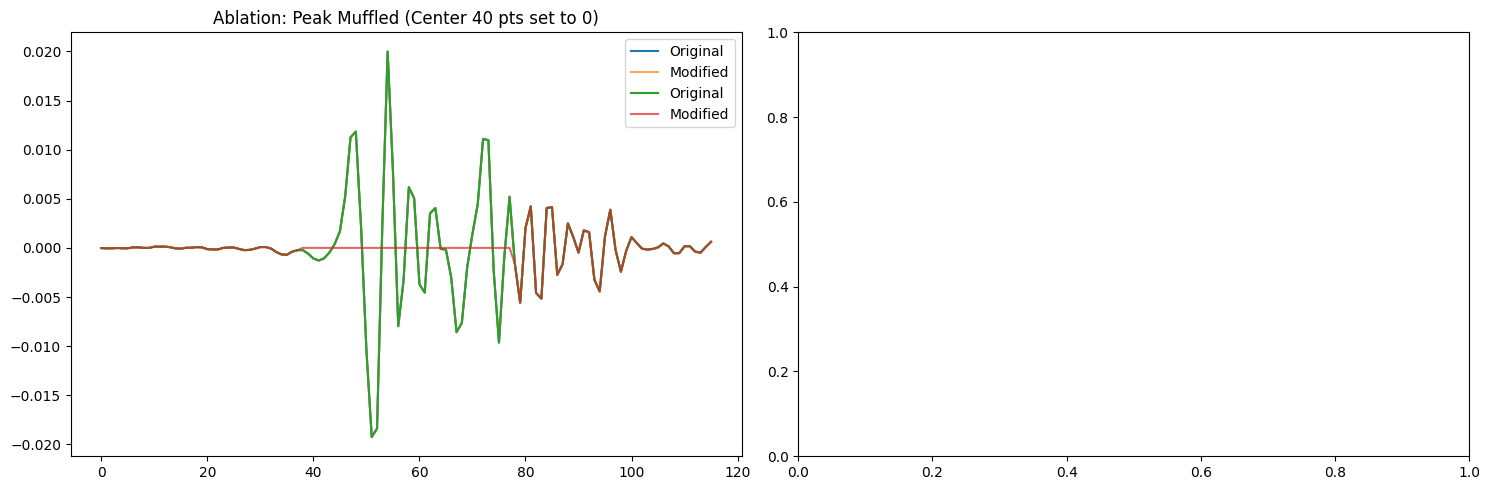


--- Ablation: Tail Removed (Only first 100 pts kept) ---
Accuracy: 0.6950
[[ 39  61]
 [  0 100]]


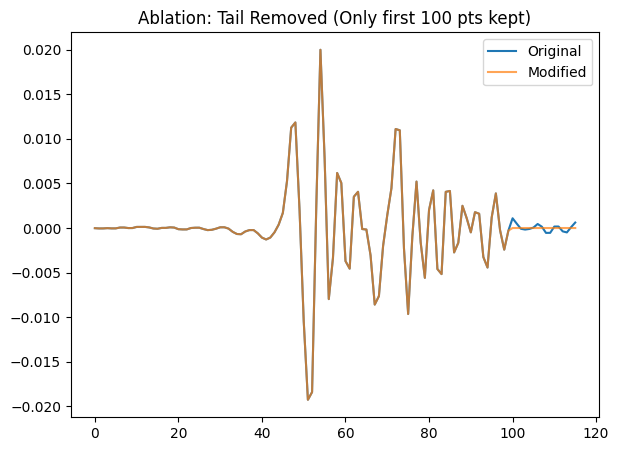

In [23]:
# --- 方法二：消融实验 (Ablation Study) ---

def ablation_test(X_data, y_data, mode='original'):
    X_modified = X_data.copy()
    
    if mode == 'kill_peak':
        # 假设 Click 峰值在中心附近，我们将中间最强的部分抹除 (比如中心 40 个点)
        mid = WAVE_LEN // 2
        X_modified[:, mid-20:mid+20] = 0
        title = "Ablation: Peak Muffled (Center 40 pts set to 0)"
    
    elif mode == 'kill_tail':
        # 斩断尾巴：只保留前 100 个点（假设 Click 在前部），后面全部清零
        # 这模拟了“完全没有混响”的情况
        X_modified[:, 100:] = 0
        title = "Ablation: Tail Removed (Only first 100 pts kept)"
    else:
        title = "Original Signal"

    # 使用已经训练好的 RBF 模型进行预测
    preds = svm_pipeline.predict(X_modified)
    acc = accuracy_score(y_data, preds)
    
    # 打印混淆矩阵看召回率变化
    print(f"\n--- {title} ---")
    print(f"Accuracy: {acc:.4f}")
    print(confusion_matrix(y_data, preds))
    
    # 可视化一个处理后的样本
    plt.subplot(1, 2, 1)
    plt.plot(X_data[0], label='Original')
    plt.plot(X_modified[0], label='Modified', alpha=0.7)
    plt.title(title)
    plt.legend()

# 运行消融实验
plt.figure(figsize=(15, 5))
print("正在测试模型对不同波形特征的依赖度...")

# 1. 测试原始 Hard Set
ablation_test(X_hard, y_hard, mode='original')

# 2. 抹除峰值：看模型是否还能靠残留能量识别
plt.subplot(1, 2, 2)
ablation_test(X_hard, y_hard, mode='kill_peak')

plt.tight_layout()
plt.show()

# 3. 斩断尾巴：看模型是否受混响影响
plt.figure(figsize=(15, 5))
ablation_test(X_hard, y_hard, mode='kill_tail')
plt.show()